In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load csv file
car=pd.read_csv('used_car.csv')

In [3]:
# data set values
car.head(10)

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel
5,Ford EcoSport Titanium 1.5L TDCi,Ford,2015,Ask For Price,"59,000 kms",Diesel
6,Ford Figo,Ford,2012,"1,75,000","41,000 kms",Diesel
7,Hyundai Eon,Hyundai,2013,"1,90,000","25,000 kms",Petrol
8,Ford EcoSport Ambiente 1.5L TDCi,Ford,2016,"8,30,000","24,530 kms",Diesel
9,Maruti Suzuki Alto K10 VXi AMT,Maruti,2015,"2,50,000","60,000 kms",Petrol


In [4]:
# count of row and column
car.shape

(892, 6)

In [5]:
# dataset's basic information
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


In [6]:
# Creating backup copy
backup=car.copy()

In [7]:
# unique value of year
car['year'].unique()

array(['2007', '2006', '2018', '2014', '2015', '2012', '2013', '2016',
       '2010', '2017', '2008', '2011', '2019', '2009', '2005', '2000',
       '...', '150k', 'TOUR', '2003', 'r 15', '2004', 'Zest', '/-Rs',
       'sale', '1995', 'ara)', '2002', 'SELL', '2001', 'tion', 'odel',
       '2 bs', 'arry', 'Eon', 'o...', 'ture', 'emi', 'car', 'able', 'no.',
       'd...', 'SALE', 'digo', 'sell', 'd Ex', 'n...', 'e...', 'D...',
       ', Ac', 'go .', 'k...', 'o c4', 'zire', 'cent', 'Sumo', 'cab',
       't xe', 'EV2', 'r...', 'zest'], dtype=object)

In [8]:
# cleaning of year's value.
# Filter out non-numeric values in the 'year' column
car['year'] = car['year'].astype(str)
car = car[car['year'].str.isnumeric()]

# Convert 'year' column to integer
car['year'] = car['year'].astype(int)

# Verify the result
print(car['year'])

0      2007
1      2006
2      2018
3      2014
4      2014
       ... 
886    2009
888    2018
889    2013
890    2014
891    2014
Name: year, Length: 842, dtype: int32


In [9]:
# unique value of price
car['Price'].unique()

array(['80,000', '4,25,000', 'Ask For Price', '3,25,000', '5,75,000',
       '1,75,000', '1,90,000', '8,30,000', '2,50,000', '1,82,000',
       '3,15,000', '4,15,000', '3,20,000', '10,00,000', '5,00,000',
       '3,50,000', '1,60,000', '3,10,000', '75,000', '1,00,000',
       '2,90,000', '95,000', '1,80,000', '3,85,000', '1,05,000',
       '6,50,000', '6,89,999', '4,48,000', '5,49,000', '5,01,000',
       '4,89,999', '2,80,000', '3,49,999', '2,84,999', '3,45,000',
       '4,99,999', '2,35,000', '2,49,999', '14,75,000', '3,95,000',
       '2,20,000', '1,70,000', '85,000', '2,00,000', '5,70,000',
       '1,10,000', '4,48,999', '18,91,111', '1,59,500', '3,44,999',
       '4,49,999', '8,65,000', '6,99,000', '3,75,000', '2,24,999',
       '12,00,000', '1,95,000', '3,51,000', '2,40,000', '90,000',
       '1,55,000', '6,00,000', '1,89,500', '2,10,000', '3,90,000',
       '1,35,000', '16,00,000', '7,01,000', '2,65,000', '5,25,000',
       '3,72,000', '6,35,000', '5,50,000', '4,85,000', '3,29,5

In [10]:
# Ensure the 'Price' column is of type str
car['Price'] = car['Price'].astype(str)

# Step 1: Remove rows where 'Price' contains non-numerical values like 'Ask For Price'
car = car[car['Price'].str.contains(r'^\d', na=False)]  # Keep only rows where 'Price' starts with a digit
print(car.shape)
# Remove commas from the 'Price' column
car['Price'] = car['Price'].str.replace(',', '')

# Drop rows where 'Price' is NaN
car = car.dropna(subset=['Price'])
print(car.shape)
# Convert the 'Price' column to integers
car['Price'] = car['Price'].astype(int)

print(car['Price'])

(819, 6)
(819, 6)
0       80000
1      425000
3      325000
4      575000
6      175000
        ...  
886    300000
888    260000
889    390000
890    180000
891    160000
Name: Price, Length: 819, dtype: int32


In [11]:
# unique value of kms
car['kms_driven'].unique()

array(['45,000 kms', '40 kms', '28,000 kms', '36,000 kms', '41,000 kms',
       '25,000 kms', '24,530 kms', '60,000 kms', '30,000 kms',
       '32,000 kms', '48,660 kms', '4,000 kms', '16,934 kms',
       '43,000 kms', '35,550 kms', '39,522 kms', '39,000 kms',
       '55,000 kms', '72,000 kms', '15,975 kms', '70,000 kms',
       '23,452 kms', '35,522 kms', '48,508 kms', '15,487 kms',
       '82,000 kms', '20,000 kms', '68,000 kms', '38,000 kms',
       '27,000 kms', '33,000 kms', '46,000 kms', '16,000 kms',
       '47,000 kms', '35,000 kms', '30,874 kms', '15,000 kms',
       '29,685 kms', '1,30,000 kms', '19,000 kms', '54,000 kms',
       '13,000 kms', '38,200 kms', '22,000 kms', '50,000 kms',
       '13,500 kms', '3,600 kms', '45,863 kms', '60,500 kms',
       '12,500 kms', '18,000 kms', '13,349 kms', '29,000 kms',
       '44,000 kms', '42,000 kms', '14,000 kms', '49,000 kms',
       '36,200 kms', '51,000 kms', '1,04,000 kms', '33,333 kms',
       '33,600 kms', '5,600 kms', '7,500 km

In [12]:
# Step 1: Clean the 'kms_driven' column
car['kms_driven'] = car['kms_driven'].str.replace(',', '')  # Remove commas
car['kms_driven'] = car['kms_driven'].str.split().str[0]  # Remove 'kms' by keeping the first part

# Step 2: Remove rows where 'kms_driven' contains 'petrol' or empty values
car = car[car['kms_driven'].notnull()]  # Remove empty/NaN values
print(car.shape)

car = car[~car['kms_driven'].str.contains('Petrol', na=False)]  # Remove rows with 'Petrol'
print(car.shape)

# Step 3: Convert the 'kms_driven' column to integer type
car['kms_driven'] = car['kms_driven'].astype(int)

# Verify the result
print(car[['kms_driven']].head())



(819, 6)
(817, 6)
   kms_driven
0       45000
1          40
3       28000
4       36000
6       41000


In [13]:
# unique value of fuel_types
car['fuel_type'].unique()

array(['Petrol', 'Diesel', nan, 'LPG'], dtype=object)

In [14]:
# hnadle the fuel values
car=car[~car['fuel_type'].isna()]
# car = car[car['fuel_type'].notnull()]

car['fuel_type']


0      Petrol
1      Diesel
3      Petrol
4      Diesel
6      Diesel
        ...  
883    Petrol
885    Diesel
886    Petrol
888    Diesel
889    Diesel
Name: fuel_type, Length: 816, dtype: object

In [15]:
# take a 3 word from the name . 
car['name']=car['name'].str.split().str.slice(0,3).str.join(' ')
car['name']

0         Hyundai Santro Xing
1         Mahindra Jeep CL550
3           Hyundai Grand i10
4      Ford EcoSport Titanium
6                   Ford Figo
                ...          
883        Maruti Suzuki Ritz
885            Tata Indica V2
886      Toyota Corolla Altis
888              Tata Zest XM
889        Mahindra Quanto C8
Name: name, Length: 816, dtype: object

In [16]:
# Resetting the index of the final cleaned data
car=car.reset_index(drop=True)
car

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand i10,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport Titanium,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...
811,Maruti Suzuki Ritz,Maruti,2011,270000,50000,Petrol
812,Tata Indica V2,Tata,2009,110000,30000,Diesel
813,Toyota Corolla Altis,Toyota,2009,300000,132000,Petrol
814,Tata Zest XM,Tata,2018,260000,27000,Diesel


In [17]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        816 non-null    object
 1   company     816 non-null    object
 2   year        816 non-null    int32 
 3   Price       816 non-null    int32 
 4   kms_driven  816 non-null    int32 
 5   fuel_type   816 non-null    object
dtypes: int32(3), object(3)
memory usage: 28.8+ KB


In [18]:
# giving a numeric colum value
car.describe()

,year,Price,kms_driven
count,816.000000,8.160000e+02,816.000000
mean,2012.444853,4.117176e+05,46275.531863
std,4.002992,4.751844e+05,34297.428044
min,1995.000000,3.000000e+04,0.000000
25%,2010.000000,1.750000e+05,27000.000000
50%,2013.000000,2.999990e+05,41000.000000
75%,2015.000000,4.912500e+05,56818.500000
max,2019.000000,8.500003e+06,400000.000000


In [19]:
# we have one car which value  is  85l
car[car['Price']>4e6]

,name,company,year,Price,kms_driven,fuel_type
534,Mahindra XUV500 W6,Mahindra,2014,8500003,45000,Diesel


In [20]:
# we have only 1 value which's price is greatear that 40L
# we will keep everythong which is less than 40L
car=car[car['Price']<4e6].reset_index(drop=True)
car

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand i10,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport Titanium,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...
810,Maruti Suzuki Ritz,Maruti,2011,270000,50000,Petrol
811,Tata Indica V2,Tata,2009,110000,30000,Diesel
812,Toyota Corolla Altis,Toyota,2009,300000,132000,Petrol
813,Tata Zest XM,Tata,2018,260000,27000,Diesel


In [21]:
# save everything in another copy. 
car.to_csv('cleaned Car.csv')

In [22]:
car.describe(include='all')

,name,company,year,Price,kms_driven,fuel_type
count,815,815,815.000000,8.150000e+02,815.000000,815
unique,254,25,NaN,NaN,NaN,3
top,Maruti Suzuki Swift,Maruti,NaN,NaN,NaN,Petrol
freq,51,221,NaN,NaN,NaN,428
mean,NaN,NaN,2012.442945,4.017933e+05,46277.096933,NaN
std,NaN,NaN,4.005079,3.815888e+05,34318.459638,NaN
min,NaN,NaN,1995.000000,3.000000e+04,0.000000,NaN
25%,NaN,NaN,2010.000000,1.750000e+05,27000.000000,NaN
50%,NaN,NaN,2013.000000,2.999990e+05,41000.000000,NaN
75%,NaN,NaN,2015.000000,4.900000e+05,56879.000000,NaN


# visualize the data and relations


Checking relationship of Company with Price

C:\Users\admin1\AppData\Local\Temp\ipykernel_4068\2482941323.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')


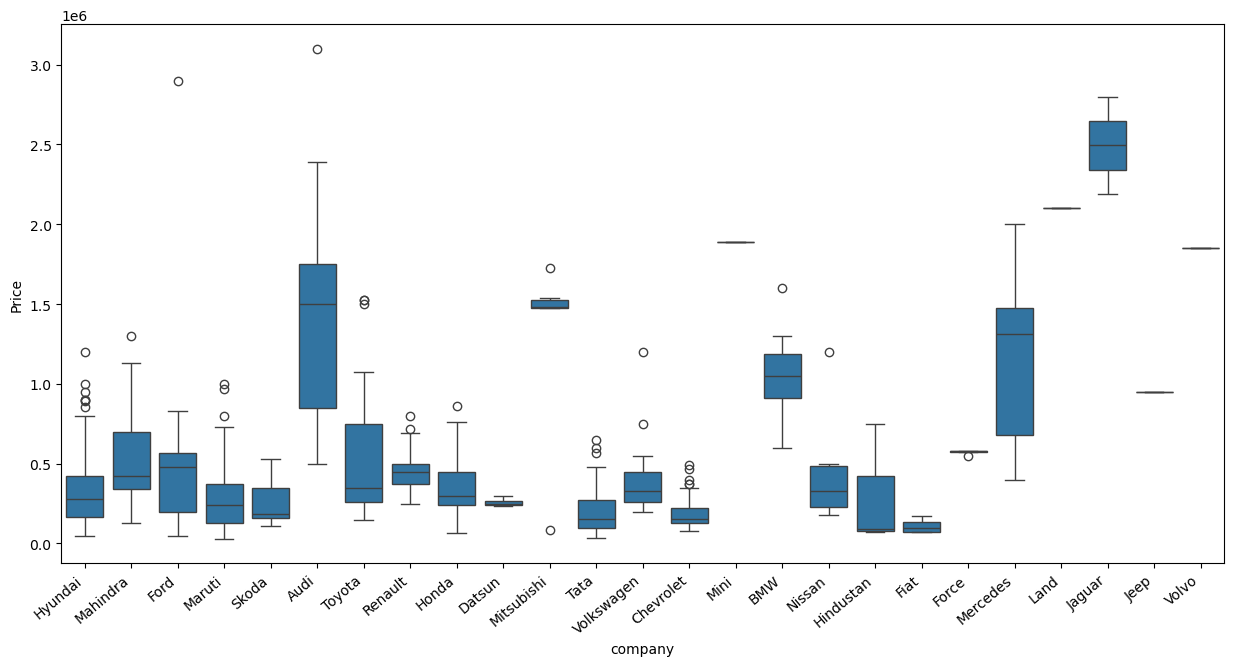

In [23]:
# finding outliers and work on it for better  model performance
plt.subplots(figsize=(15,7))
ax=sns.boxplot(x='company',y='Price',data=car)
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')
plt.show()

"The price range for used cars varies considerably across different companies, with some brands showing a wider spread of prices."

C:\Users\admin1\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 13.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\admin1\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 13.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\admin1\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 6.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\admin1\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 10.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\admin1\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 7.7% of the poi

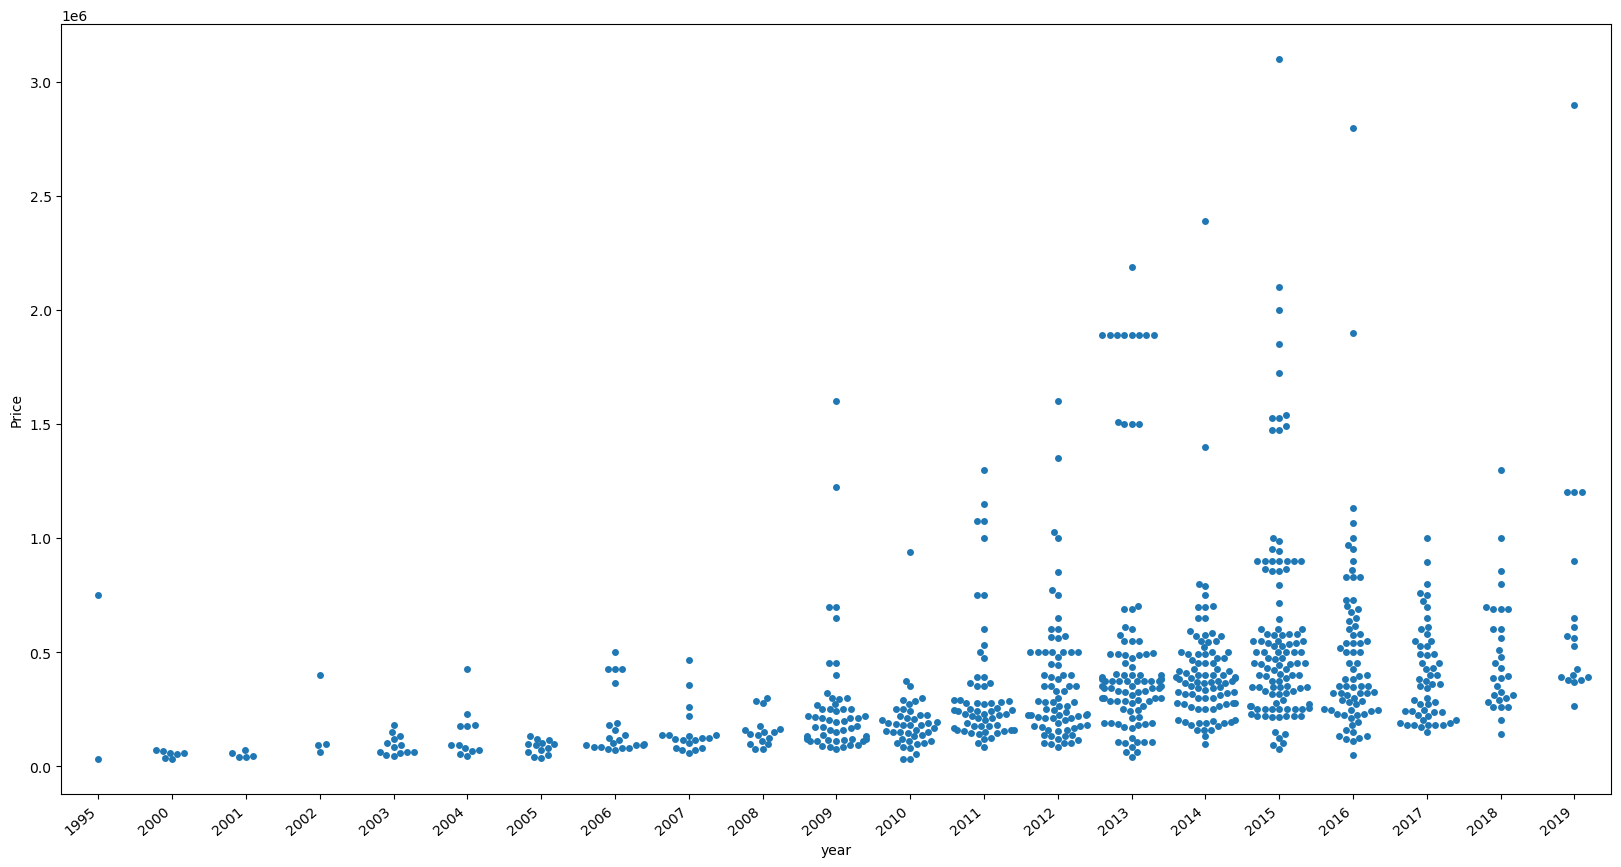

In [24]:
# year with price

plt.subplots(figsize=(20,10))
ax=sns.swarmplot(x='year',y='Price',data=car)
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')
plt.show()

shows a positive trend between the year of a car and its price. As the year increases (i.e., the car is newer), the price generally tends to increase as well. This suggests that newer cars are typically more expensive than older ones.

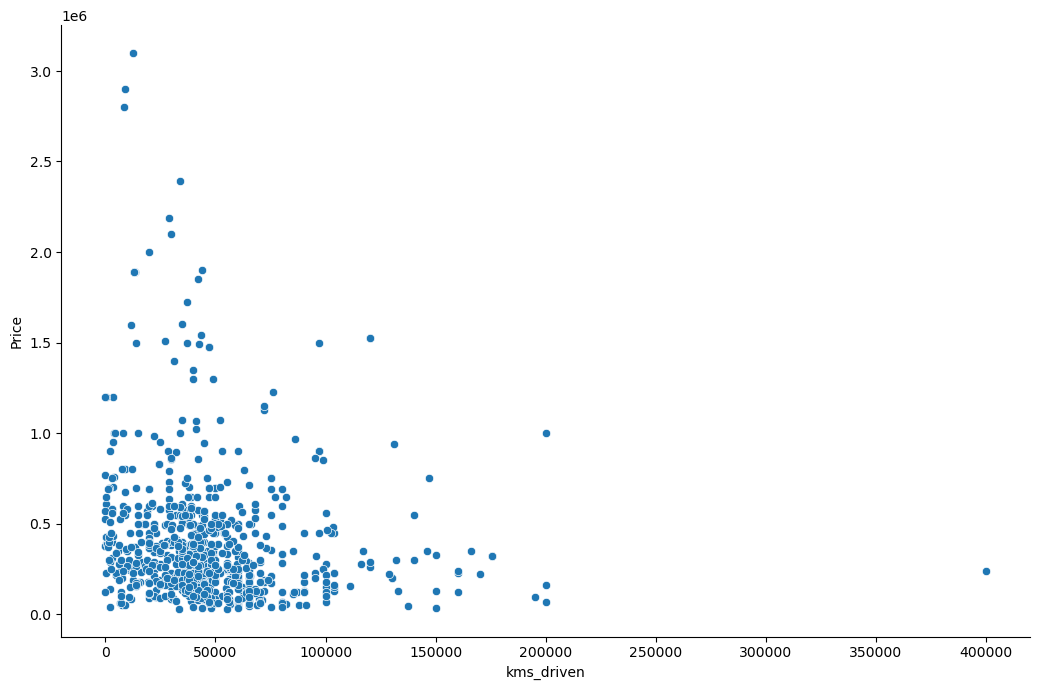

In [25]:
# kms_driven with price
# internally replot  call  a scatter and line based on (kind = line)
sns.relplot(x='kms_driven',y='Price',data=car,height=7,aspect=1.5)
# sns.relplot(x='kms_driven',y='Price',data=car,height=7,aspect=1.5 , kind='scatter')

 we can conclude that there is a general negative relationship between the price of a car and the kilometers it has driven. This means that, generally, cars with higher mileage tend to have lower prices. However, there are some exceptions to this trend. For example, you might see some high-mileage cars with relatively high prices, perhaps due to their brand, condition, or specific features.

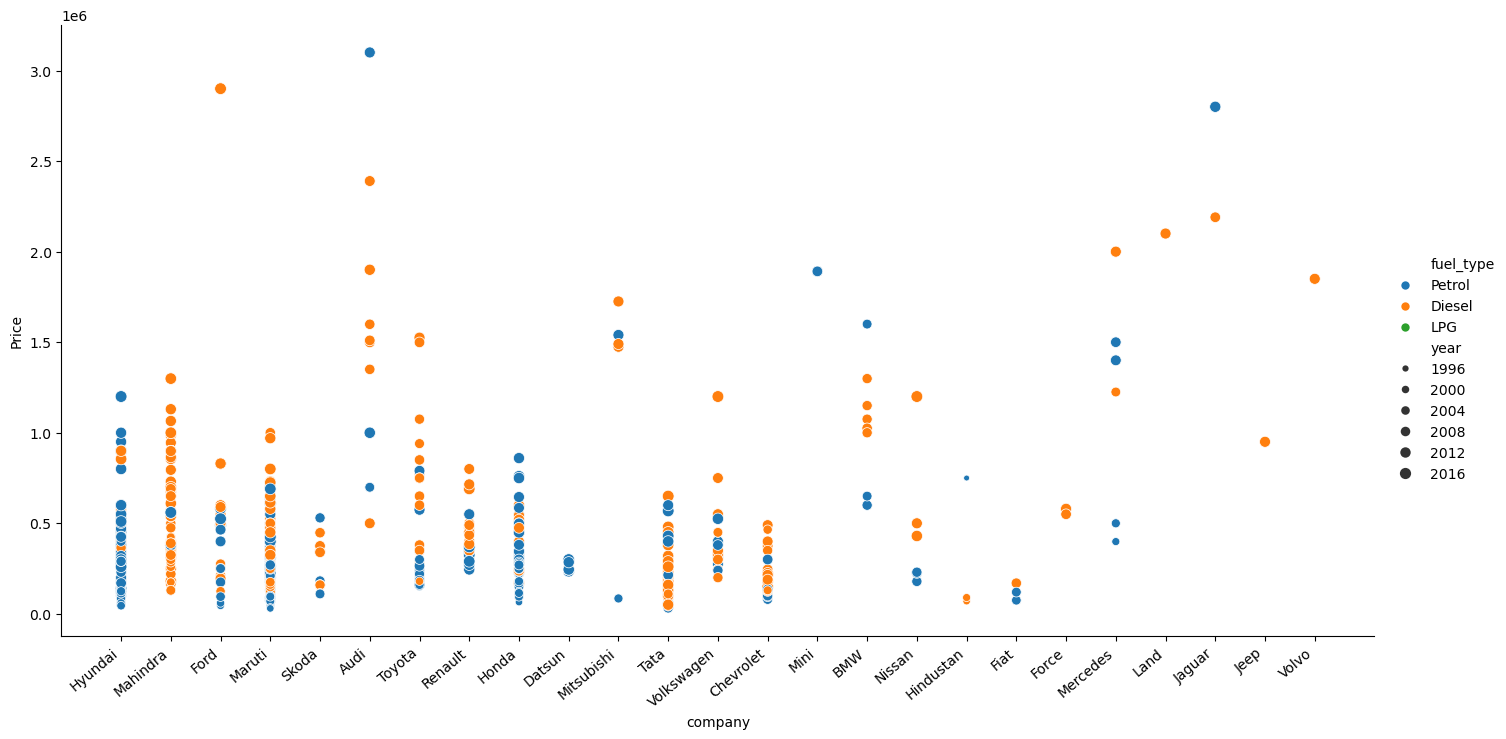

In [26]:
# relate together : price with Fuel_type, year, Company type

ax=sns.relplot(x='company',y='Price',data=car,hue='fuel_type',size='year',height=7,aspect=2)
ax.set_xticklabels(rotation=40,ha='right')

we can say that newer diesel cars from premium brands tend to have higher prices compared to older petrol or CNG cars from budget brands.


<Axes: xlabel='fuel_type', ylabel='Price'>

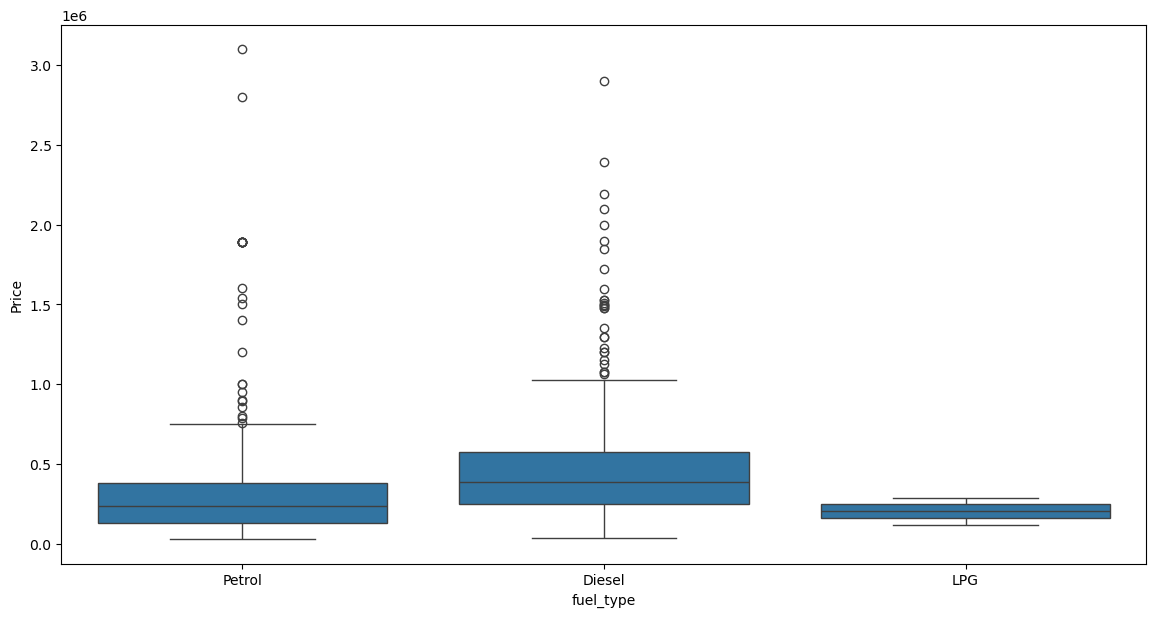

In [27]:
# fuel type with price
plt.subplots(figsize=(14,7))
sns.boxplot(x='fuel_type',y='Price',data=car)


we can say by visalize above graph that here is car price by fuel type is in order of Diesel > Petrol > LPG .

In [28]:
# Extract data for train model
x=car[['name','company','year','kms_driven','fuel_type']]
y=car['Price']

In [29]:
x

,name,company,year,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,2007,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,2006,40,Diesel
2,Hyundai Grand i10,Hyundai,2014,28000,Petrol
3,Ford EcoSport Titanium,Ford,2014,36000,Diesel
4,Ford Figo,Ford,2012,41000,Diesel
...,...,...,...,...,...
810,Maruti Suzuki Ritz,Maruti,2011,50000,Petrol
811,Tata Indica V2,Tata,2009,30000,Diesel
812,Toyota Corolla Altis,Toyota,2009,132000,Petrol
813,Tata Zest XM,Tata,2018,27000,Diesel


In [30]:
y.shape

(815,)

# Applying Train Test Split


In [31]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2)


## creatinng model 

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

Creating an OneHotEncoder object to contain all the possible categories


In [33]:
# instead of lable encoder use Onehotencoder  bcz it give nutral order or number to indiviusal value. and creaet a new column and assign the 0/1.
ohe=OneHotEncoder()
ohe.fit(x[['name','company','fuel_type']])

OneHotEncoder()

In [34]:
# Creating a column transformer to transform categorical columns
column_trans=make_column_transformer((OneHotEncoder(categories=ohe.categories_),['name','company','fuel_type']),
            remainder='passthrough') # passing another column as it is with numeric value

In [35]:
# Linear Regression Model
lr=LinearRegression()

# Making a pipeline
pipe=make_pipeline(column_trans,lr)

# Fitting the model
pipe.fit(X_train,y_train)

C:\Users\admin1\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(categories=[array(['Audi A3 Cabriolet', 'Audi A4 1.8', 'Audi A4 2.0', 'Audi A6 2.0',
       'Audi A8', 'Audi Q3 2.0', 'Audi Q5 2.0', 'Audi Q7', 'BMW 3 Series',
       'BMW 5 Series', 'BMW 7 Series', 'BMW X1', 'BMW X1 sDrive20d',
       'BMW X1 xDrive20d', 'Chevrolet Beat', 'Chevrolet Beat...
                                                                            array(['Audi', 'BMW', 'Chevrolet', 'Datsun', 'Fiat', 'Force', 'Ford',
       'Hindustan', 'Honda', 'Hyundai', 'Jaguar', 'Jeep', 'Land',
       'Mahindra', 'Maruti', 'Mercedes', 'Mini', 'Mitsubishi', 'Nissan',
       'Renault', 'Skoda', 'Tata', 'Toyota', 'Volkswagen', 'Volvo'],
      dtype=object),
                                                                            array(['Diesel', 'LPG', 'Petrol'], dtype=object)]),
                                                  ['name', 'company',
                                                   'fuel_type'])])),
                ('linearregression', LinearRegression())])

In [36]:
y_pred=pipe.predict(X_test)

In [37]:
# Checking R2 Score

r2_score(y_test,y_pred)

0.6481873645172909

### checking the highest suitable  state

In [38]:
# Finding the model with a random state of TrainTestSplit where the model was found to give almost 0.92 as r2_score

scores=[]
for i in range(1000):
    X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=i)
    lr=LinearRegression()
    pipe=make_pipeline(column_trans,lr)
    pipe.fit(X_train,y_train)
    y_pred=pipe.predict(X_test)
    scores.append(r2_score(y_test,y_pred))

In [39]:
np.argmax(scores)

433

In [40]:
scores[np.argmax(scores)]

0.8457042416667213

In [41]:
# example 
pipe.predict(pd.DataFrame(columns=X_test.columns,data=np.array(['Maruti Suzuki Swift','Maruti',2019,100,'Petrol']).reshape(1,5)))

array([431205.11067147])

In [42]:
# The best model is found at a certain random state

X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=np.argmax(scores))
lr=LinearRegression()
pipe=make_pipeline(column_trans,lr)
pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)
r2_score(y_test,y_pred)

0.8457042416667213

In [43]:
#  the value of evaluted model

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

print(f"R² Score     : {r2:.4f}")
print(f"MAE          : ₹{mae:,.2f}")
print(f"MSE          : ₹{mse:,.2f}")
print(f"RMSE         : ₹{rmse:,.2f}")


R² Score     : 0.8457
MAE          : ₹108,494.18
MSE          : ₹26,536,803,167.30
RMSE         : ₹162,901.21


C:\Users\admin1\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


print(f"R² Score     : {r2:.4f}")
print("→ R² (Coefficient of Determination) explains how much of the variation in car prices the model captures.")
print("→ A score of 0.8457 means the model explains ~84.57% of the price variation. This shows a strong model fit.")

print(f"MAE          : ₹{mae:,.2f}")
print("→ MAE (Mean Absolute Error) tells us the average absolute difference between predicted and actual prices.")
print("→ ₹1.08 lakh means that, on average, the predicted car price is off by ₹1.08 lakh. This is within acceptable range.")

print(f"MSE          : ₹{mse:,.2f}")
print("→ MSE (Mean Squared Error) penalizes larger errors more heavily, as it squares each error.")
print("→ It is useful for understanding how consistent the errors are — a lower value is better.")

print(f"RMSE         : ₹{rmse:,.2f}")
print("→ RMSE (Root Mean Squared Error) gives the error in the same unit as the target (i.e., ₹).")
print("→ ₹1.62 lakh RMSE shows that while most predictions are close, some errors can be larger — which is typical in real-world price predictions.")


In [44]:
# import pickle
# pickle.dump(pipe,open('LinearRegressionModel.pkl','wb'))

In [45]:
# predict the price of 1 model as a example
pipe.predict(pd.DataFrame(columns=X_test.columns,data=np.array(['Maruti Suzuki Swift','Maruti',2019,100,'Petrol']).reshape(1,5)))

array([458900.81022717])

In [46]:
# print updated dataset
car.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand i10,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport Titanium,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel


In [47]:
# take list of all car model
pipe.steps[0][1].transformers[0][1].categories[0]


array(['Audi A3 Cabriolet', 'Audi A4 1.8', 'Audi A4 2.0', 'Audi A6 2.0',
       'Audi A8', 'Audi Q3 2.0', 'Audi Q5 2.0', 'Audi Q7', 'BMW 3 Series',
       'BMW 5 Series', 'BMW 7 Series', 'BMW X1', 'BMW X1 sDrive20d',
       'BMW X1 xDrive20d', 'Chevrolet Beat', 'Chevrolet Beat Diesel',
       'Chevrolet Beat LS', 'Chevrolet Beat LT', 'Chevrolet Beat PS',
       'Chevrolet Cruze LTZ', 'Chevrolet Enjoy', 'Chevrolet Enjoy 1.4',
       'Chevrolet Sail 1.2', 'Chevrolet Sail UVA', 'Chevrolet Spark',
       'Chevrolet Spark 1.0', 'Chevrolet Spark LS', 'Chevrolet Spark LT',
       'Chevrolet Tavera LS', 'Chevrolet Tavera Neo', 'Datsun GO T',
       'Datsun Go Plus', 'Datsun Redi GO', 'Fiat Linea Emotion',
       'Fiat Petra ELX', 'Fiat Punto Emotion', 'Force Motors Force',
       'Force Motors One', 'Ford EcoSport', 'Ford EcoSport Ambiente',
       'Ford EcoSport Titanium', 'Ford EcoSport Trend',
       'Ford Endeavor 4x4', 'Ford Fiesta', 'Ford Fiesta SXi', 'Ford Figo',
       'Ford Figo Diese

In [48]:
## import numpy as np
import pandas as pd

# Take input from the user
name = input("Enter Car Name: ")
company = input("Enter Company: ")
fuel_type = input("Enter Fuel Type: ")
year = int(input("Enter Year of Purchase: "))
kms_driven = int(input("Enter Kilometers Driven: "))

# Prepare input in the same format as training data (x.columns)
input_data = pd.DataFrame(columns=['name', 'company', 'year', 'kms_driven', 'fuel_type'],
                          data=[[name, company, year, kms_driven, fuel_type]])

# Make prediction using the trained pipeline
prediction = pipe.predict(input_data)

# Format the predicted price
formatted_price = f"{prediction[0]:,.2f}"  # comma and 2 decimals

# Output
print(f"\nPredicted price of your {name} is: ₹{formatted_price}")


Enter Car Name:  BMW 7 Series
Enter Company:  BMW
Enter Fuel Type:  Diesel
Enter Year of Purchase:  2024
Enter Kilometers Driven:  600000



Predicted price of your BMW 7 Series is: ₹1,512,658.73


In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
import numpy as np

# Define the categories correctly for OneHotEncoder
name_categories = np.array(['Audi A3 Cabriolet', 'Audi A4 1.8', 'Audi A4 2.0', 'Audi A6 2.0', 'Audi A8', 
                            'Audi Q3 2.0', 'Audi Q5 2.0', 'Audi Q7', 'BMW 3 Series', 'BMW 5 Series', 
                            'BMW 7 Series', 'BMW X1', 'BMW X1 sDrive20d', 'BMW X1 xDrive20d', 
                            'Chevrolet Beat', 'Chevrolet Beat Diesel'])

company_categories = np.array(['Audi', 'BMW', 'Chevrolet', 'Datsun', 'Fiat', 'Force', 'Ford',
                               'Hindustan', 'Honda', 'Hyundai', 'Jaguar', 'Jeep', 'Land', 
                               'Mahindra', 'Maruti', 'Mercedes', 'Mini', 'Mitsubishi', 
                               'Nissan', 'Renault', 'Skoda', 'Tata', 'Toyota', 'Volkswagen', 
                               'Volvo'])

fuel_type_categories = np.array(['Diesel', 'LPG', 'Petrol'])

# Define ColumnTransformer with OneHotEncoder for categorical features
column_transformer = ColumnTransformer(
    transformers=[
        ('onehotencoder', 
         OneHotEncoder(categories=[name_categories, company_categories, fuel_type_categories]), 
         ['name', 'company', 'fuel_type'])
    ],
    remainder='passthrough'  # Keep the other columns as is
)

# Create the pipeline
pipeline = Pipeline(steps=[
    ('columntransformer', column_transformer),
    ('linearregression', LinearRegression())
])

# The pipeline is now defined correctly
